In [20]:
import pandas as pd #import numpy as np

df = pd.read_csv("../data/e1_nutrients.csv") # read the csv file into a pandas dataframe
display(df.head()) #display the first 5 rows of the dataframe
print(df.info()) #print information about the dataframe
display(df.describe()) #display descriptive statistics of the dataframe
print(df.isna().sum()) #print the number of missing values in each column


,Depth,NITRITE,NITRATE+NITRITE,AMMONIA,SILICATE,PHOSPHATE
0,0,0.03,0.38,0.00,1.27,0.06
1,10,0.03,0.45,0.98,1.14,0.06
2,20,0.23,2.08,1.10,2.54,0.27
3,30,0.04,0.39,0.00,1.15,0.08
4,40,0.28,2.19,1.11,2.59,0.19


<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Depth            2496 non-null   int64  
 1   NITRITE          2496 non-null   float64
 2   NITRATE+NITRITE  2496 non-null   float64
 3   AMMONIA          2496 non-null   float64
 4   SILICATE         2496 non-null   float64
 5   PHOSPHATE        2496 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 117.1 KB
None


,Depth,NITRITE,NITRATE+NITRITE,AMMONIA,SILICATE,PHOSPHATE
count,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000
mean,26.919071,0.210601,2.905465,0.519247,1.939455,0.290741
std,19.729713,0.328292,2.260390,0.654011,1.076337,0.175216
min,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000
25%,10.000000,0.040000,0.430000,0.100000,1.010000,0.160000
50%,30.000000,0.110000,3.030000,0.240000,2.080000,0.300000
75%,40.000000,0.230000,4.972500,0.640000,2.750000,0.410000
max,60.000000,2.900000,8.350000,4.170000,8.820000,2.560000


Depth              0
NITRITE            0
NITRATE+NITRITE    0
AMMONIA            0
SILICATE           0
PHOSPHATE          0
dtype: int64


In [21]:
# SEPERATE THE INPUTS AND TARGETS

X = df.drop(columns=["NITRITE"]) #drop the "NITRITE" column from the dataframe and assign it to X
y = df["NITRITE"] # assign the "NITRITE" column to y


In [22]:
#CROSS VALIDATION AND MODEL TRAINING
from sklearn.model_selection import KFold # import KFold from sklearn.model_selection

cv = KFold(n_splits=5, shuffle=True, random_state=42) # create a KFold object with 5 splits, shuffling the data and setting a random state for reproducibility




In [23]:
#MODEL BUILDING

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()) # baseline mode
    ]),
    "Random Forest": RandomForestRegressor( # could be a good starting point
        n_estimators=200,
        random_state=42
    ),
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor( # gives a neural network with moderate size and enough iterations to converge more often.
            hidden_layer_sizes=(50, 25),
            max_iter=3000,
            random_state=42
        ))
    ])
}


In [24]:
#MEASURE CROSS-VALIDATED MSE


import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score

results = []

for name, model in models.items():
    scores = -cross_val_score( #negative due to the fact the scoring function returns negative values, so this flips it back to positive scoring
        model, X, y,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    results.append({
        "Model": name,
        "Mean MSE": scores.mean(), #average MSE across the 5 folds
        "Std MSE": scores.std()
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Mean MSE,Std MSE
0,Linear Regression,0.095249,0.009400
1,Random Forest,0.052304,0.011014
2,Neural Network,0.066714,0.009636


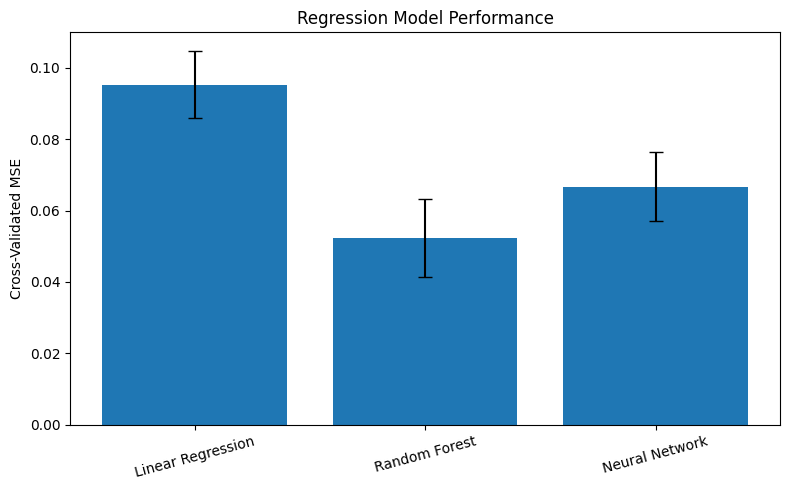

In [25]:
#PLOTTING RESULTS

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Mean MSE"], yerr=results_df["Std MSE"], capsize=5)
plt.ylabel("Cross-Validated MSE")
plt.title("Regression Model Performance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [26]:
#showing model does predict here

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test[:5])
    print(name)
    print("Predictions:", preds)
    print("True values:", y_test.iloc[:5].values)
    print()

Linear Regression
Predictions: [0.05170578 0.05131972 0.23181563 0.18182822 0.26940071]
True values: [0.   0.   0.17 0.19 2.61]

Random Forest
Predictions: [0.0000e+00 3.0000e-04 1.9555e-01 1.2605e-01 1.3947e+00]
True values: [0.   0.   0.17 0.19 2.61]

Neural Network
Predictions: [ 0.00963558 -0.01474953  0.09517791  0.14356181  0.60767818]
True values: [0.   0.   0.17 0.19 2.61]



In [27]:
#optimisation :(

import math

def mccormick(x, y):
    return math.sin(x + y) + (x - y)**2 - 1.5*x + 2.5*y + 1

In [28]:
#generation of random solutiosn for optimisation

import random
import numpy as np

random.seed(42)

points = np.array([
    [random.uniform(-5, 5), random.uniform(-5, 5)]
    for _ in range(500)
])

fitness = np.array([mccormick(x, y) for x, y in points])